# Assignment 1

## Imports

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

## Loading Dataset

In [2]:
data = pd.read_csv("datasets/StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Tasks:

### 1. Box Plot
    1. Create a box plot comparing math scores across gender categories.
    2. Show median, quartiles, and outliers.
    3. Title: "Math Score Distribution by Gender".
    4. Label x-axis as "Gender".
    5. Label y-axis as "Math Score".

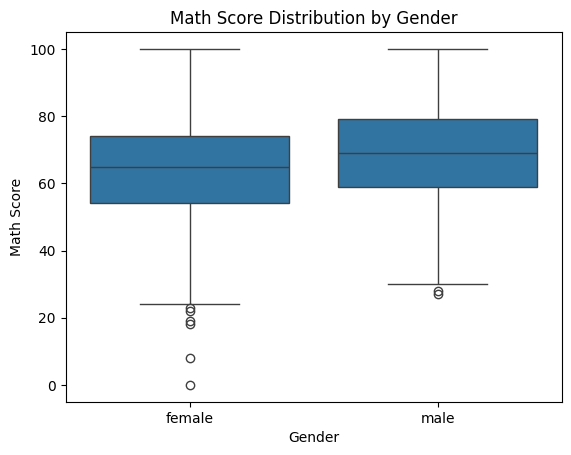

In [3]:
plt.figure()
sns.boxplot(x="gender", y="math score", data=data)

plt.title("Math Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")

plt.savefig("plots/assignment1/boxplot_math_gender.png")
plt.show()

### 2. Violin Plot
    1. Visualize writing score distribution by parental level of education.
    2. Use different colors for each education level.
    3. Title: "Writing Score Distribution by Parental Education".
    4. Label axes appropriately.

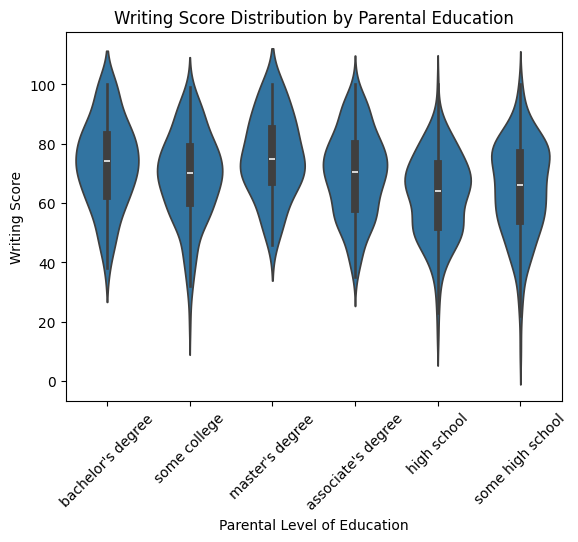

In [4]:
plt.figure()
sns.violinplot(
    x="parental level of education",
    y="writing score",
    data=data
)

plt.title("Writing Score Distribution by Parental Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Writing Score")

plt.xticks(rotation=45)

plt.savefig("plots/assignment1/violin_writing_parental.png")
plt.show()

### 3. Heatmap
    1. Create correlation heatmap of math, reading, and writing scores.
    2. Display colorbar.
    3. Annotate correlation values.
    4. Title: "Correlation Heatmap of Student Scores".

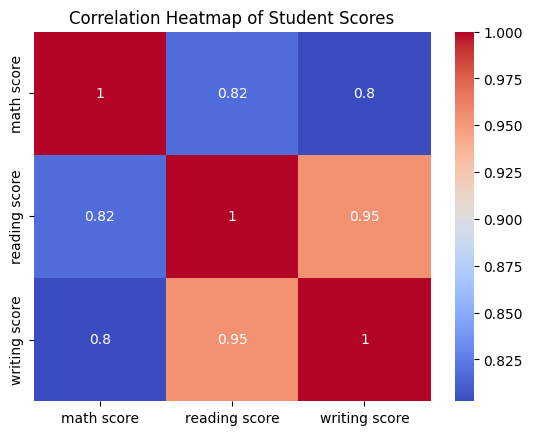

In [5]:
scores = data[["math score", "reading score", "writing score"]]
corr = scores.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Student Scores")

plt.savefig("plots/assignment1/heatmap_scores.png")
plt.show()

### 4. Subplots (Dashboard View)
    Create 2×2 subplot layout:
    1. Histogram of math scores.
    2. Box plot of reading scores by gender.
    3. Scatter plot of math vs writing scores.
    4. Bar chart of average writing score by gender.
    5. Add common figure title.

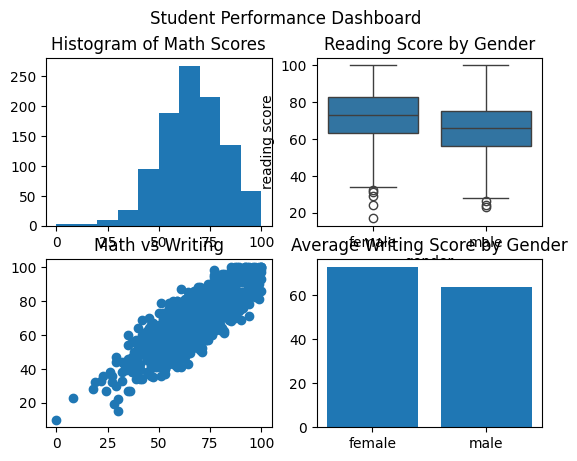

In [6]:
fig, axes = plt.subplots(2, 2)

# Histogram
axes[0,0].hist(data["math score"])
axes[0,0].set_title("Histogram of Math Scores")

# Box plot
sns.boxplot(x="gender", y="reading score", data=data, ax=axes[0,1])
axes[0,1].set_title("Reading Score by Gender")

# Scatter plot
axes[1,0].scatter(data["math score"], data["writing score"])
axes[1,0].set_title("Math vs Writing")

# Bar chart
avg = data.groupby("gender")["writing score"].mean()
axes[1,1].bar(avg.index, avg.values)
axes[1,1].set_title("Average Writing Score by Gender")

fig.suptitle("Student Performance Dashboard")

plt.savefig("plots/assignment1/dashboard.png")
plt.show()

### 5. Draw a house diagram using matplotlib.patches.

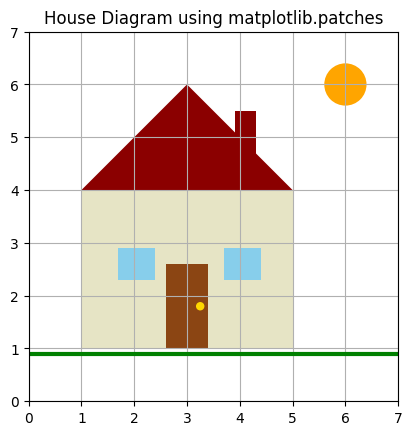

In [7]:
fig, ax = plt.subplots()

# House base
house = patches.Rectangle((1,1),4,3,facecolor="#e6e4c5")
ax.add_patch(house)

# Roof
roof = patches.Polygon([[1,4],[3,6],[5,4]],facecolor="darkred")
ax.add_patch(roof)

# Door
door = patches.Rectangle((2.6,1),0.8,1.6,facecolor="saddlebrown")
ax.add_patch(door)

# Door knob
knob = patches.Circle((3.25,1.8),0.08,facecolor="gold")
ax.add_patch(knob)

# Windows
window1 = patches.Rectangle((1.7,2.3),0.7,0.6,facecolor="skyblue")
window2 = patches.Rectangle((3.7,2.3),0.7,0.6,facecolor="skyblue")
ax.add_patch(window1)
ax.add_patch(window2)

# Chimney
chimney = patches.Rectangle((3.9,4.5),0.4,1,facecolor="darkred")
ax.add_patch(chimney)

# Sun
sun = patches.Circle((6,6),0.4,facecolor="orange")
ax.add_patch(sun)

# Ground line
ax.plot([0,7],[0.9,0.9],color="green",linewidth=3)

# Axis settings
ax.set_xlim(0,7)
ax.set_ylim(0,7)
ax.set_aspect("equal")
ax.grid()
plt.title("House Diagram using matplotlib.patches")

plt.savefig("plots/assignment1/house_diagram.png")
plt.show()

### 6. Generate 3D surface plot for z = x² + y².

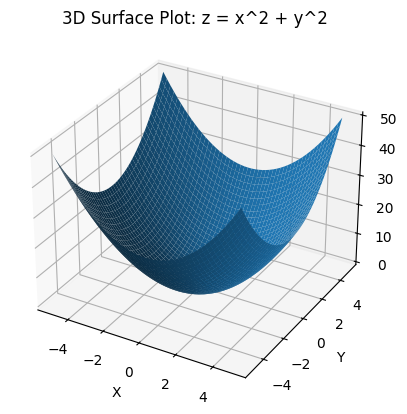

In [8]:
x = np.linspace(-5,5,50)
y = np.linspace(-5,5,50)
X, Y = np.meshgrid(x,y)
Z = X**2 + Y**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("3D Surface Plot: z = x^2 + y^2")

plt.savefig("plots/assignment1/surface_plot.png")
plt.show()

### 7. Image Processing using matplotlib.image

#### Load & Display Image

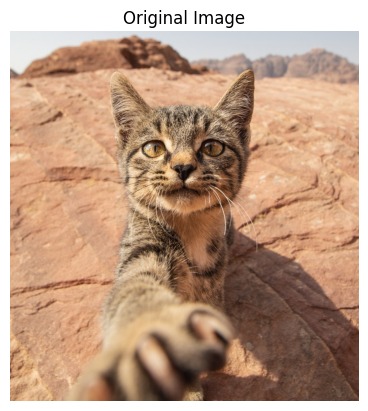

In [10]:
img = mpimg.imread("plots/assignment1/cat1.jpg")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.savefig("plots/assignment1/cat_original_image1.png")
plt.show()

#### Convert to Grayscale

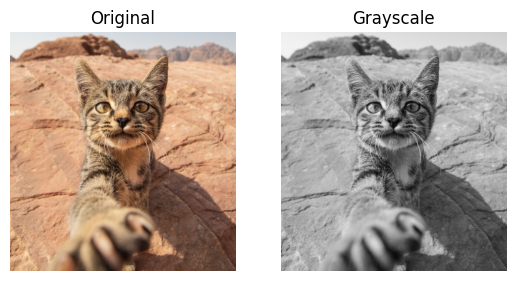

In [11]:
gray = img.mean(axis=2)

fig, ax = plt.subplots(1,2)

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale")
ax[1].axis("off")

plt.savefig("plots/assignment1/cat_grayscale1.png")
plt.show()

#### Crop + Flip

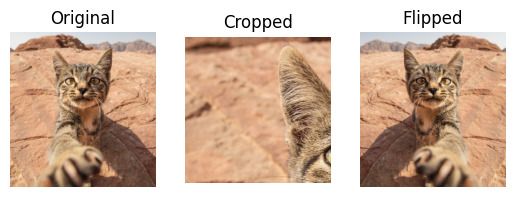

In [12]:
cropped = img[100:400, 100:400]
flipped = img[:, ::-1]

fig, ax = plt.subplots(1,3)

ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(cropped); ax[1].set_title("Cropped"); ax[1].axis("off")
ax[2].imshow(flipped); ax[2].set_title("Flipped"); ax[2].axis("off")

plt.savefig("plots/assignment1/cat_crop_flip1.png")
plt.show()

#### Brightness & Contrast

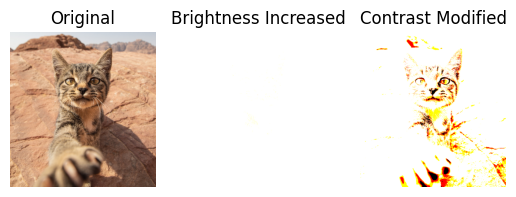

In [13]:
bright = img + 0.2
bright = bright.clip(0,1)

contrast = (img - img.mean()) * 1.5 + img.mean()
contrast = contrast.clip(0,1)

fig, ax = plt.subplots(1,3)

ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(bright); ax[1].set_title("Brightness Increased"); ax[1].axis("off")
ax[2].imshow(contrast); ax[2].set_title("Contrast Modified"); ax[2].axis("off")

plt.savefig("plots/assignment1/cat_brightness_contrast1.png")
plt.show()

#### Watermark

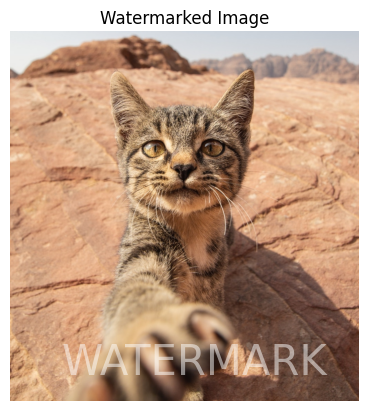

In [14]:
plt.imshow(img)
plt.text(
    150,1000,
    "WATERMARK",
    fontsize=30,
    color="white",
    alpha=0.5
)

plt.axis("off")
plt.title("Watermarked Image")

plt.savefig("plots/assignment1/cat_watermark1.png")
plt.show()